In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import scanpy as sc

from sklearn.metrics import adjusted_rand_score

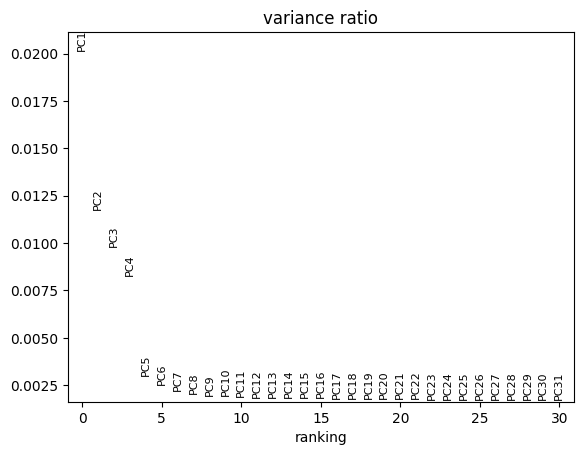

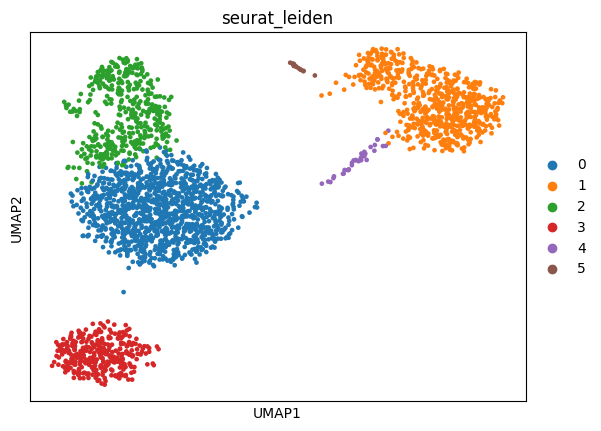

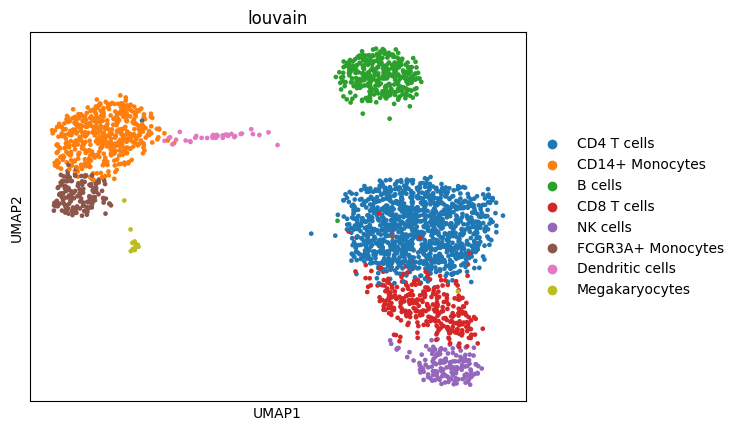

ARI between Seurat Leiden and original Louvain: 0.8374890186482035


In [3]:
pbmc = sc.datasets.pbmc3k()
pbmc_processed = sc.datasets.pbmc3k_processed()
sc.pp.filter_cells(pbmc, min_genes=200)
sc.pp.filter_genes(pbmc, min_cells=3)
pbmc.var["mt"] = pbmc.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    pbmc, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)
pbmc = pbmc[pbmc.obs.n_genes_by_counts < 2500, :]
pbmc = pbmc[pbmc.obs.pct_counts_mt < 5, :]
sc.pp.normalize_total(pbmc, target_sum=1e4)
sc.pp.log1p(pbmc)
sc.pp.highly_variable_genes(pbmc, min_mean=0.0125, max_mean=3, min_disp=0.5)
pbmc = pbmc[:, pbmc.var.highly_variable]
sc.pp.regress_out(pbmc, ["total_counts", "pct_counts_mt"])
sc.pp.scale(pbmc, max_value=10)
sc.tl.pca(pbmc, svd_solver="arpack")
sc.pl.pca_variance_ratio(pbmc, log=False)
sc.pp.neighbors(pbmc, n_neighbors=10, n_pcs=50)
sc.tl.umap(pbmc)
sc.tl.leiden(pbmc, resolution=0.5, key_added="seurat_leiden")
sc.pl.umap(pbmc, color=["seurat_leiden"])
sc.pl.umap(pbmc_processed, color=["louvain"])
print(
    "ARI between Seurat Leiden and original Louvain:",
    adjusted_rand_score(pbmc.obs["seurat_leiden"], pbmc_processed.obs["louvain"]),
)

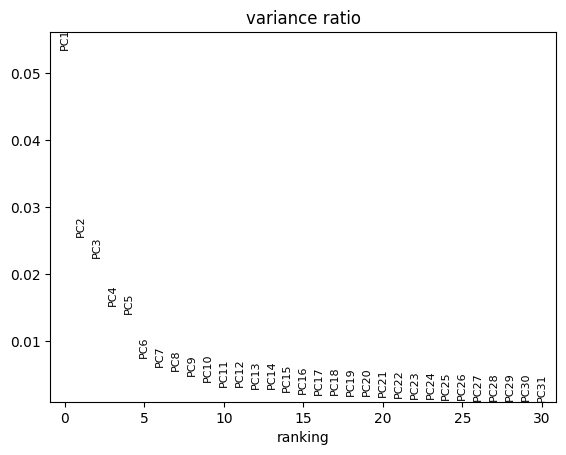

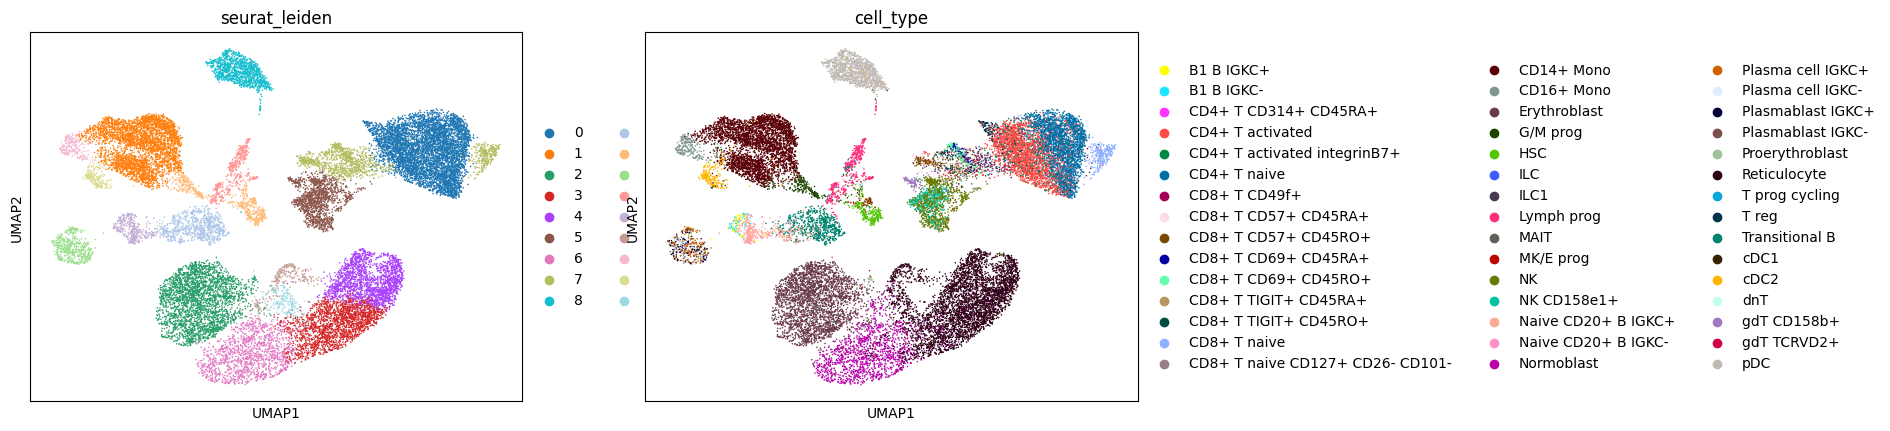

ARI between Seurat Leiden and original cell type: 0.6707314253838805


In [5]:
bmmc = sc.read_h5ad("data/bmmc.h5ad")
sc.pp.filter_cells(bmmc, min_genes=200)
sc.pp.filter_genes(bmmc, min_cells=3)
bmmc.var["mt"] = bmmc.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    bmmc, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)
bmmc = bmmc[bmmc.obs.n_genes_by_counts < 2500, :]
bmmc = bmmc[bmmc.obs.pct_counts_mt < 5, :]
sc.pp.normalize_total(bmmc, target_sum=1e4)
sc.pp.log1p(bmmc)
sc.pp.highly_variable_genes(bmmc, min_mean=0.0125, max_mean=3, min_disp=0.5)
bmmc = bmmc[:, bmmc.var.highly_variable]
sc.pp.regress_out(bmmc, ["total_counts", "pct_counts_mt"])
sc.pp.scale(bmmc, max_value=10)
sc.tl.pca(bmmc, svd_solver="arpack")
sc.pl.pca_variance_ratio(bmmc, log=False)
sc.pp.neighbors(bmmc, n_neighbors=10, n_pcs=50)
sc.tl.umap(bmmc)
sc.tl.leiden(bmmc, resolution=0.5, key_added="seurat_leiden")
sc.pl.umap(bmmc, color=["seurat_leiden", "cell_type"])
print(
    "ARI between Seurat Leiden and original cell type:",
    adjusted_rand_score(bmmc.obs["seurat_leiden"], bmmc.obs["cell_type"]),
)